<a href="https://colab.research.google.com/github/komalreddy06/heart_disease_prediction/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/heart.csv")

In [ ]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum())
print(df.duplicated().sum())



(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null 

Observation:The dataset contains 723 duplicated records,these duplicated rows can bias the machine learning model by giving repeatitive or unique values to train.Therfore these duplicated records should be removed before the training.

1.there were total 1025 rows before removing the duplicates

2.after removing the total rows will be 302

In [ ]:
df=df.drop_duplicates()
print(df.shape)

(302, 14)


In [ ]:
#libraries requires for plotting
import matplotlib.pyplot as plt
import seaborn as sns

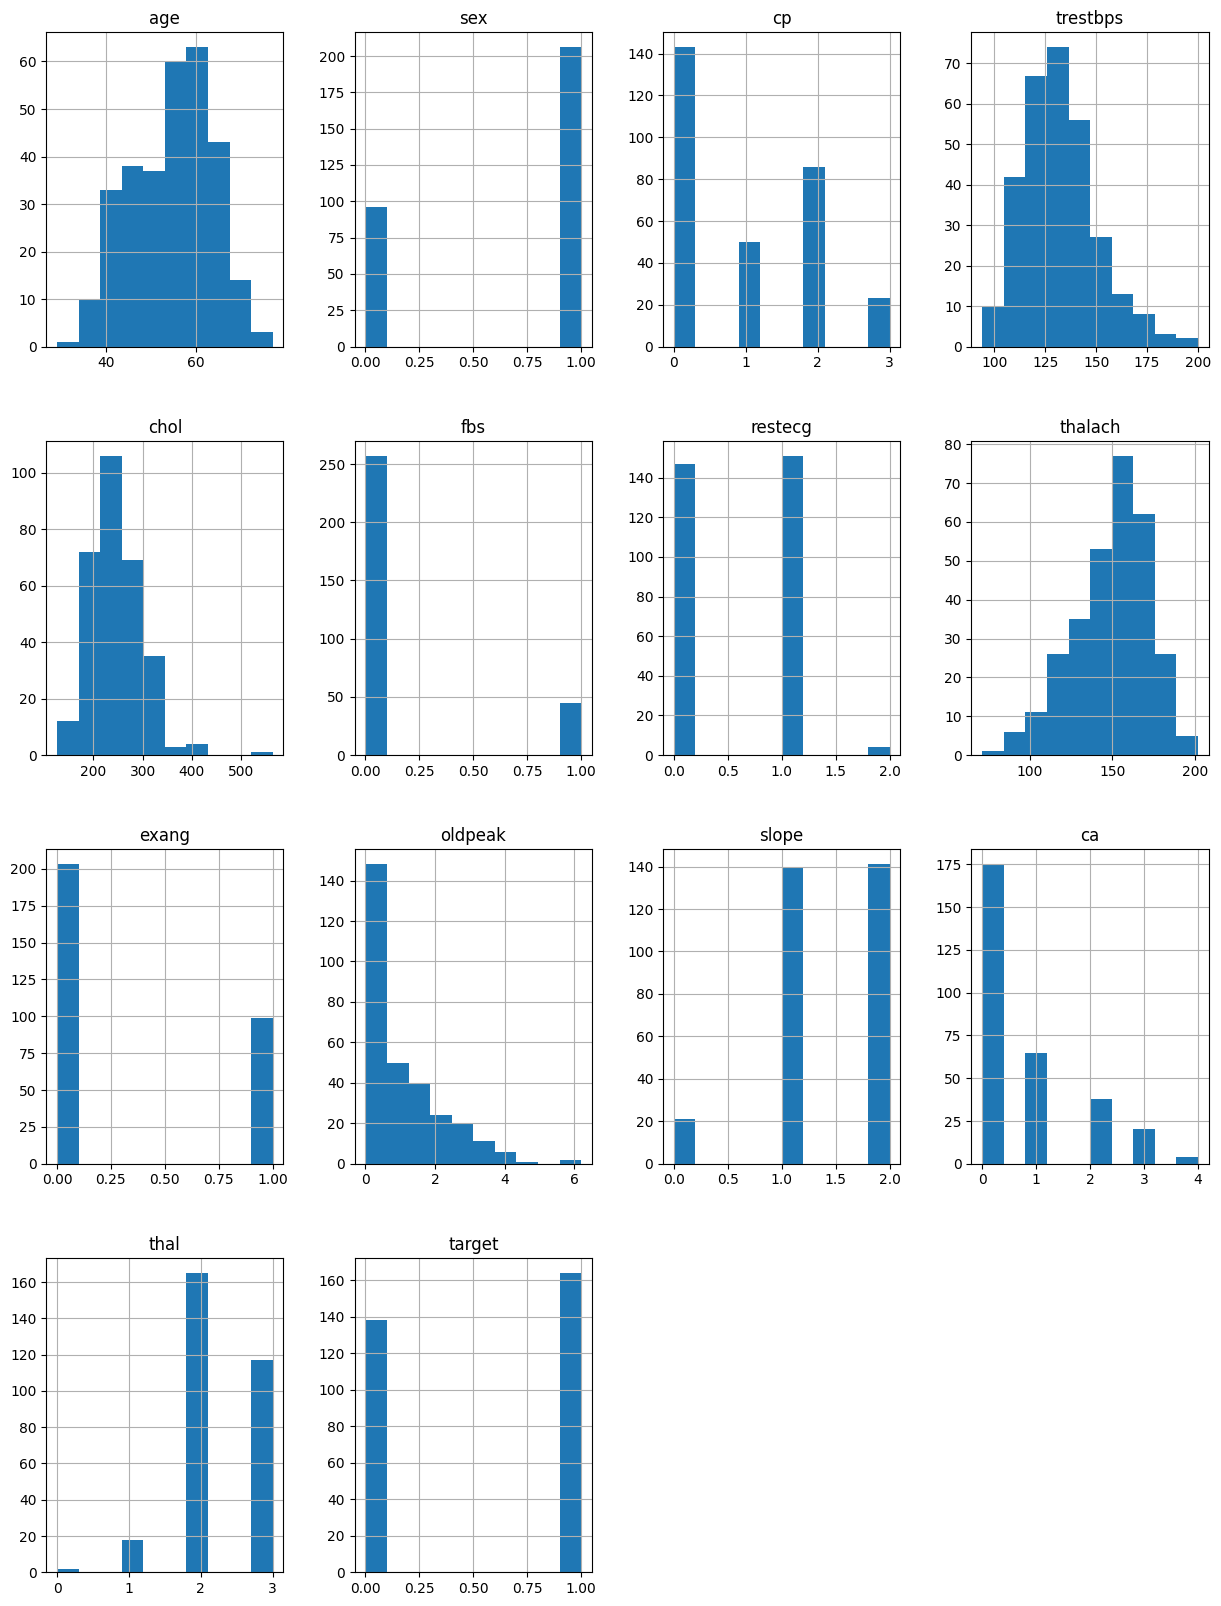

In [ ]:
#histogram of numerical variables
df.hist(figsize=(15,20))
plt.show()

1.AGE-MOST CONCENTRATED AGE IS BETWEEN 50-65
2.tresbps-Most values lie between 120 and 140 mmHg.
3.chol-Most cholesterol values are concentrated between 200 and 300 mg/dL.
4.thalach-Most values are between 140 and 170 bpm.
5.oldpeak-Most values are 0


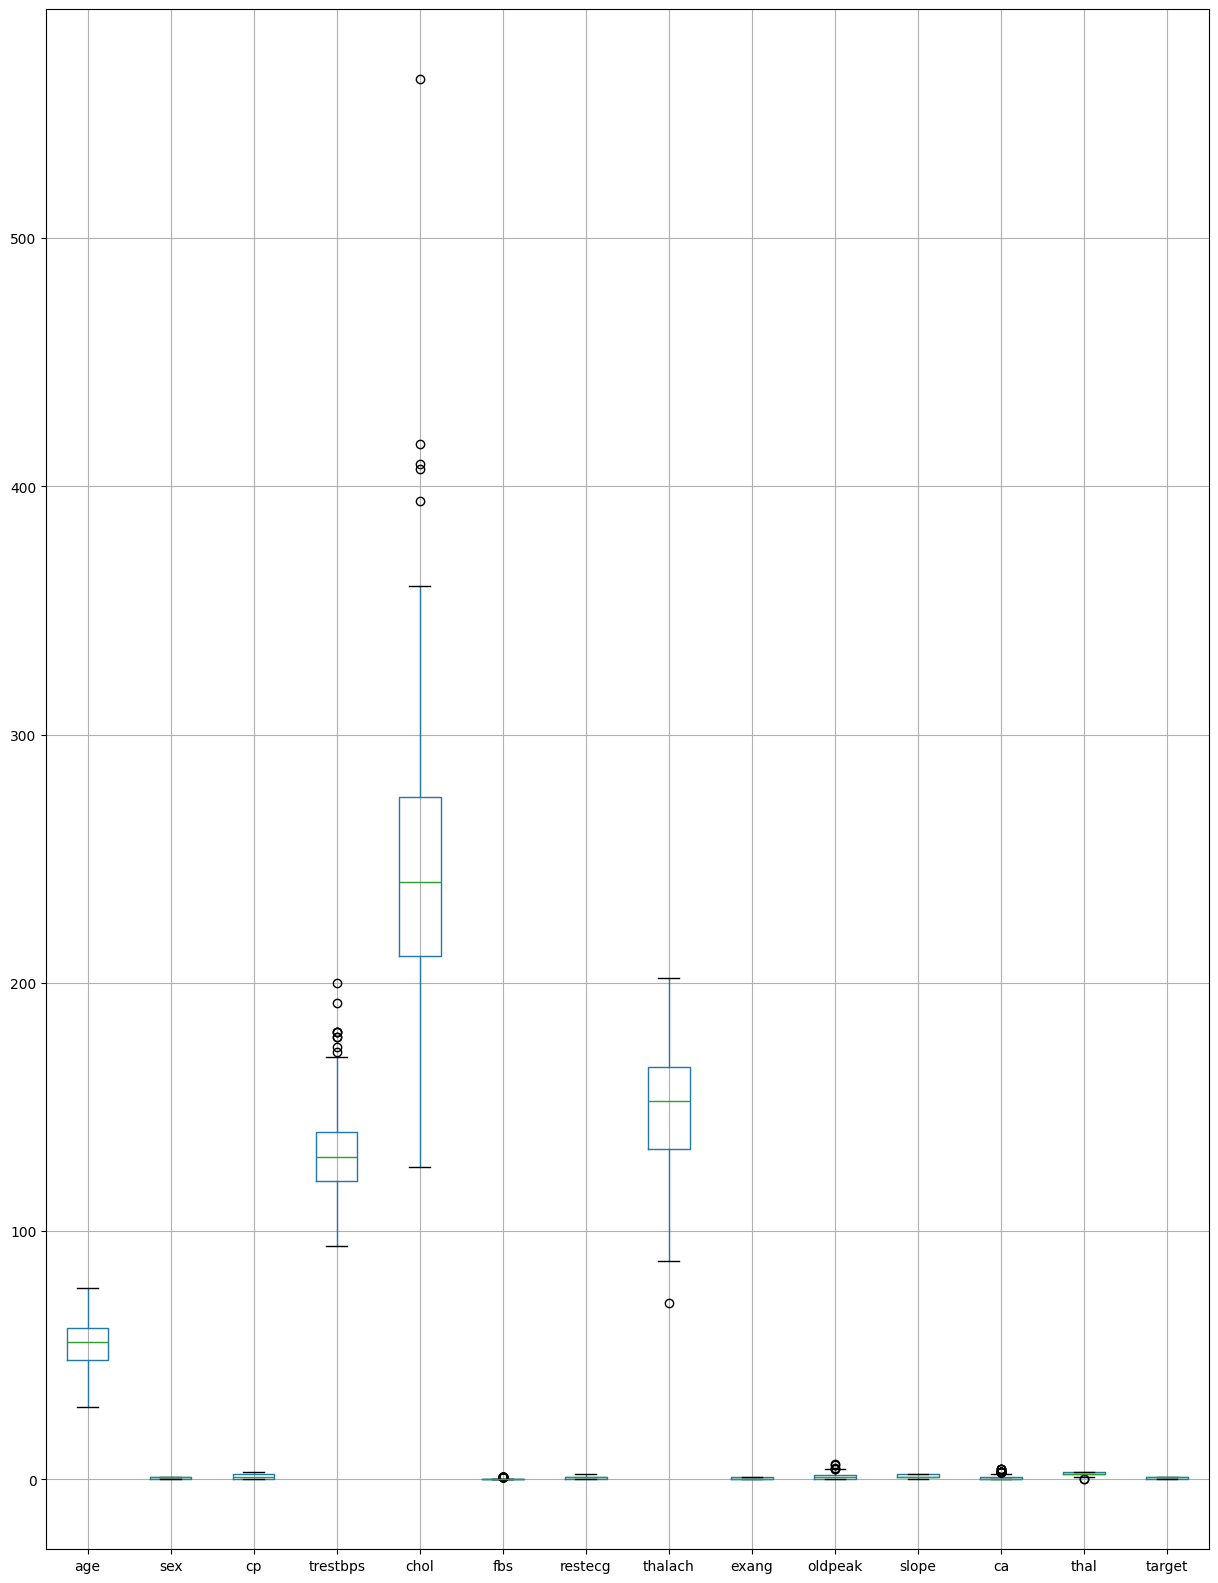

In [ ]:
#box plot
df.boxplot(figsize=(15,20))
plt.show()

Overall Observation: The boxplot reveals that features such as cholesterol (chol), resting blood pressure (trestbps), oldpeak, and ca contain noticeable outliers. These extreme values may represent genuine medical conditions rather than measurement errors, so they should be handled carefully during preprocessing instead of being removed blindly.

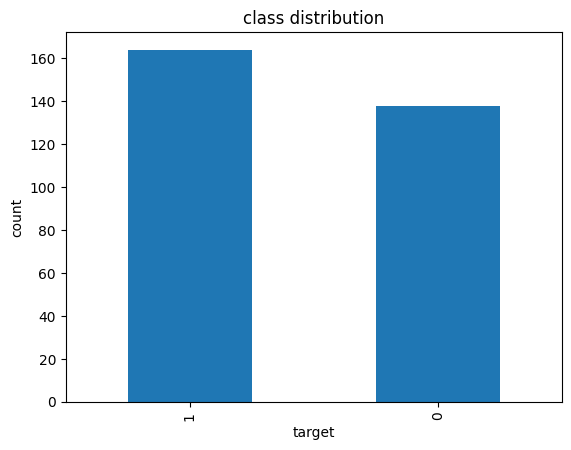

In [ ]:
df['target'].value_counts().plot(kind='bar')
plt.title("class distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

The class distribution shows that Class 1 (Heart Disease) has slightly more samples than Class 0 (No Heart Disease). However, the difference is small, indicating that the dataset is reasonably balanced.

Insight

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.094962 -0.063107  0.283121  0.207216  0.119492   
sex      -0.094962  1.000000 -0.051740 -0.057647 -0.195571  0.046022   
cp       -0.063107 -0.051740  1.000000  0.046486 -0.072682  0.096018   
trestbps  0.283121 -0.057647  0.046486  1.000000  0.125256  0.178125   
chol      0.207216 -0.195571 -0.072682  0.125256  1.000000  0.011428   
fbs       0.119492  0.046022  0.096018  0.178125  0.011428  1.000000   
restecg  -0.111590 -0.060351  0.041561 -0.115367 -0.147602 -0.083081   
thalach  -0.395235 -0.046439  0.293367 -0.048023 -0.005308 -0.007169   
exang     0.093216  0.143460 -0.392937  0.068526  0.064099  0.024729   
oldpeak   0.206040  0.098322 -0.146692  0.194600  0.050086  0.004514   
slope    -0.164124 -0.032990  0.116854 -0.122873  0.000417 -0.058654   
ca        0.302261  0.113060 -0.195356  0.099248  0.086878  0.144935   
thal      0.065317  0.211452 -0.160370  0.062870  0.096810 -0.03

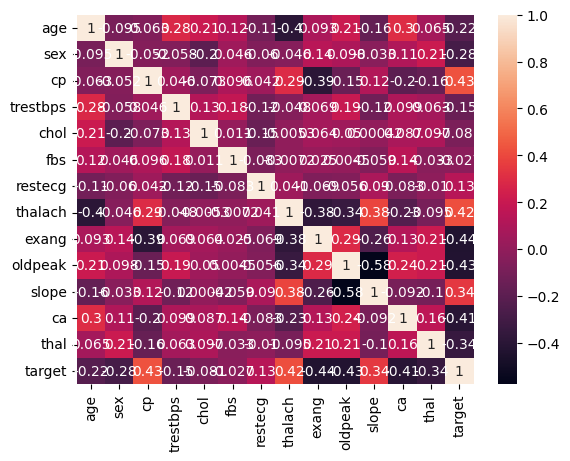

In [ ]:
print(df.corr())
correlation=df.corr()
sns.heatmap(correlation,annot=True)
plt.show()

1.FEATURE WITH THE HIGHEST POSITIVE CORRELATION WITH TARGET(CHEST PAIN TYPE=0.43)
2.OTHER POSITIVELY CORRELATED FEATURES(THALACH =0.42,SLOPE=0.34)
3.THE STRONGEST NEGATIVE CORRELATIONS ARE(EXANG=0.44,OLD PEAK=0.43,CA=0.41,THAL=0.34)
4.FEATURE TO FEATURE CORRELATION(old peak and slope=-0.58)

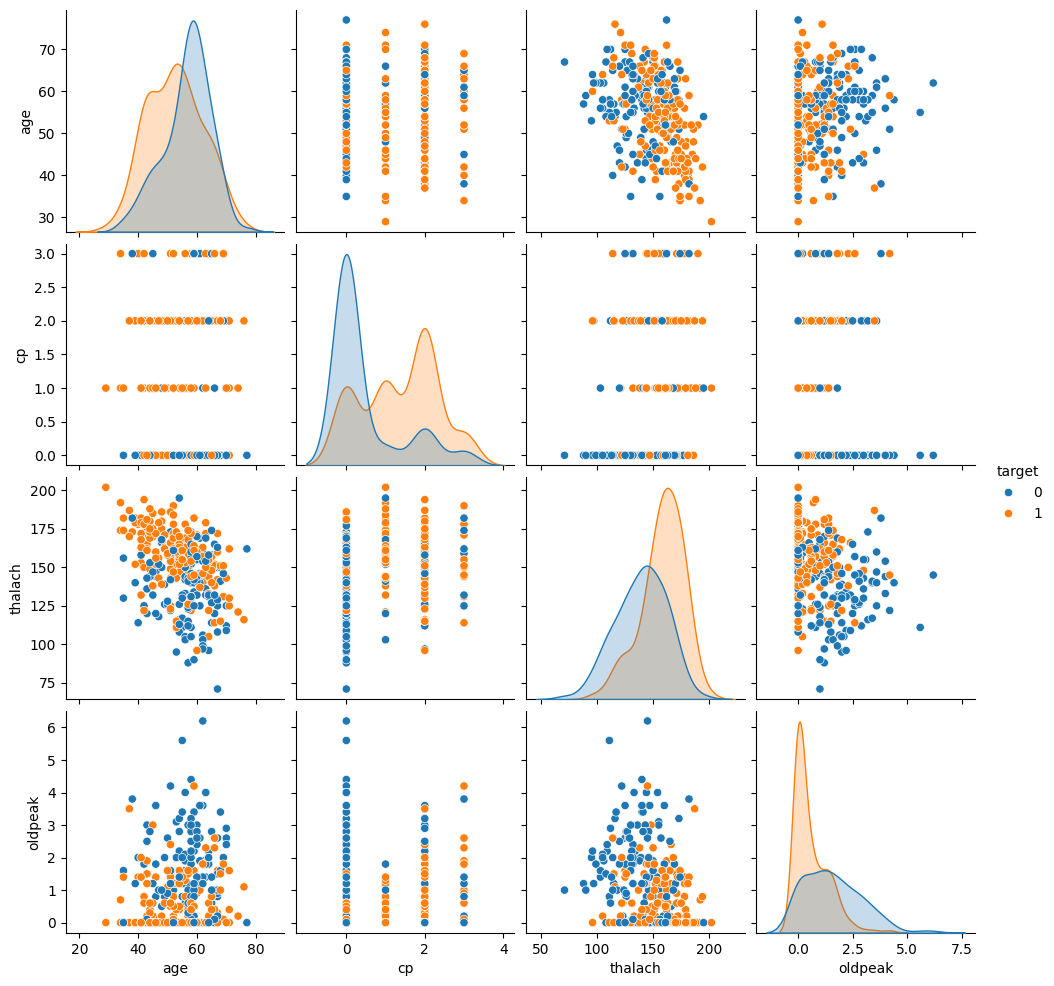

In [ ]:
#pairplots
sns.pairplot(data=df,vars=['age','cp','thalach','oldpeak'],hue='target')
plt.show()

THE DATASET HAS 0 NULL VALUES SO WE CANNOT FILL NULL VALUES WITH THE IMPUTATION METHODS

THE DATASET DOESNOT CONTAIN ANY CATEGORICAL VARIABLES STORED AS TEXT.ALL CATEGORICAL FEATURES WAS ALREADY ENCODED , SO THERE IS NO FEATURE LEFT FOR ENCODING

In [ ]:
#importing ml libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
#Step 1: Separate Features (X) and Target (y)
x=df.drop('target',axis=1)
y=df['target']
print(x.head())
print(y.head())
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scalar=StandardScaler()
scalar.fit(x_train)
x_train_scaled=scalar.transform(x_train)
x_test_scaled=scalar.transform(x_test)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  
0   2     3  
1   0     3  
2   0     3  
3   1     3  
4   3     2  
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [ ]:
#first ML MODEL PERCEPTRON
from sklearn.linear_model import Perceptron
model=Perceptron()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

In [ ]:
#accurancy
from sklearn.metrics import accuracy_score
accurancy=accuracy_score(y_test,y_pred)
print("Accurancy:",accurancy)



Accurancy: 0.7049180327868853


In [ ]:
#precision
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred)
print("Precision:",precision)

Precision: 0.72


In [ ]:
#recall
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred)
print("Recall:",recall)

Recall: 0.6206896551724138


In [ ]:
#f1 score
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred)
print("F1 SCORE:",f1)

F1 SCORE: 0.6666666666666666


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[25  7]
 [11 18]]


In [ ]:
#classification report
from sklearn.metrics import classification_report
classification=classification_report(y_test,y_pred)
print(classification)

              precision    recall  f1-score   support

           0       0.69      0.78      0.74        32
           1       0.72      0.62      0.67        29

    accuracy                           0.70        61
   macro avg       0.71      0.70      0.70        61
weighted avg       0.71      0.70      0.70        61



AUC SCORE: 0.7009698275862069


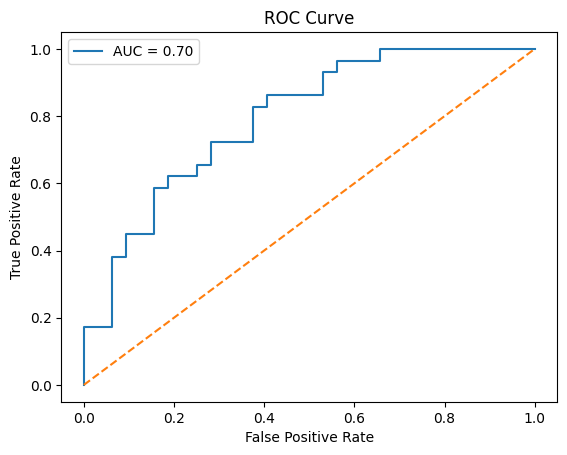

In [ ]:
#roc curve and auc
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
y_prob=model.decision_function(x_test_scaled)
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
AUC=roc_auc_score(y_test,y_pred)
print("AUC SCORE:",AUC)
# Plot ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {AUC:.2f}")
plt.plot([0,1], [0,1], linestyle='--')   # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
#knn
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print(y_pred)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
from sklearn.metrics import precision_score
PRECISION=precision_score(y_test,y_pred)
print("PRECISION:",PRECISION)
from sklearn.metrics import recall_score
RECALL=recall_score(y_test,y_pred)
print("RECALL:",RECALL)
from sklearn.metrics import f1_score
F1_SCORE=f1_score(y_test,y_pred)
print("F1 SCORE:",F1_SCORE)
from sklearn.metrics import confusion_matrix
CM_KNN=confusion_matrix(y_test,y_pred)
print("CONFUSION MATRIX:",CM_KNN)
from sklearn.metrics import classification_report
CLASSIFICATION_REPORT=classification_report(y_test,y_pred)
print("CLASSIICATION REPORT:",CLASSIFICATION_REPORT)

[1 1 0 0 0 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0
 1 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 1]
Accuracy: 0.7377049180327869
PRECISION: 0.696969696969697
RECALL: 0.7931034482758621
F1 SCORE: 0.7419354838709677
CONFUSION MATRIX: [[22 10]
 [ 6 23]]
CLASSIICATION REPORT:               precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.70      0.79      0.74        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



AUC: 0.8389008620689655


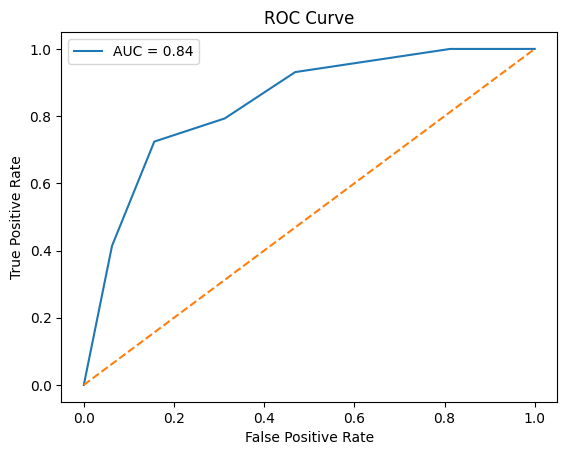

In [ ]:
#ROC CURVE AND AUC of knn
#roc and auc of dt
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = knn.predict_proba(x_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(x_train_scaled, y_train)

# Predict on test data
y_pred = dt.predict(x_test_scaled)
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_dt)

from sklearn.metrics import precision_score

precision_dt = precision_score(y_test, y_pred)
print("Precision:", precision_dt)
from sklearn.metrics import recall_score

recall_dt = recall_score(y_test, y_pred)
print("Recall:", recall_dt)

from sklearn.metrics import f1_score

f1_dt = f1_score(y_test, y_pred)
print("F1 Score:", f1_dt)

from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm_dt)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.7377049180327869
Precision: 0.7407407407407407
Recall: 0.6896551724137931
F1 Score: 0.7142857142857143
Confusion Matrix:
[[25  7]
 [ 9 20]]
              precision    recall  f1-score   support

           0       0.74      0.78      0.76        32
           1       0.74      0.69      0.71        29

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



AUC: 0.7354525862068966


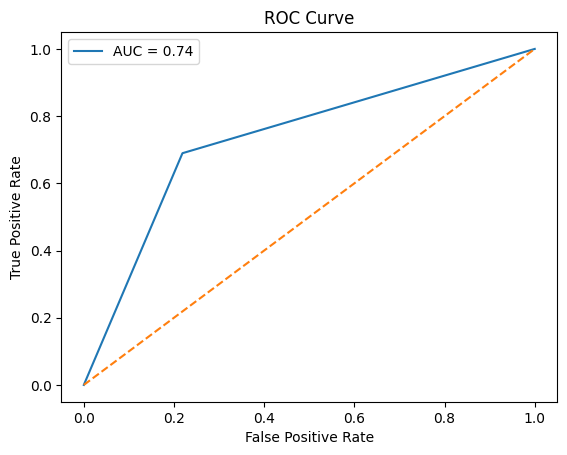

In [ ]:
#roc and auc of dt
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = dt.predict_proba(x_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()